# 04 — Modeling, Evaluasi & Interpretasi Bisnis

Tujuan:
1. Split data train/test (stratified).
2. Training model **XGBoost Classifier** dengan penanganan class imbalance.
3. Evaluasi: classification report, ROC-AUC, confusion matrix, ROC curve.
4. Cross-validation (5-fold Stratified).
5. Feature importance & interpretasi SHAP.
6. **Threshold tuning** untuk optimasi bisnis (Recall vs Precision trade-off).
7. Segmentasi risiko (High / Medium / Low) & rekomendasi aksi retensi.
8. Estimasi *business impact* (potensi penyelamatan revenue).

Semua fungsi modeling di-encapsulate di `src/model.py` sebagai single
source of truth — dipanggil ulang oleh Streamlit app untuk konsistensi.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from src.model import (
    split_data, train_model, evaluate_model, cross_validate_model,
    get_feature_importance, save_model_artifacts,
)
from src.utils import (
    FEATURES_DATA_PATH, ID_COL, TARGET_COL, RISK_THRESHOLDS,
    segment_risk, RECOMMENDATION_MAP,
)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv(FEATURES_DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (7000, 24)


,customer_id,gender,usia,kota,tenure_bulan,paket,jenis_jaringan,kuota_gb,biaya_bulanan,punya_streaming_bundle,punya_ewallet_linked,metode_bayar,jumlah_komplain_6bln,skor_kepuasan_csat,pernah_upgrade_paket,total_pemakaian_data_gb,frekuensi_login_app,churn,is_unlimited,tenure_group,usage_per_cost,high_complain_flag,low_csat_flag,engagement_score
0,CUST-00000,1,1.421422,7,-0.815370,2,1,25,-0.045032,1,1,3,2,5,0,-0.020301,1.058319,0,0,1,-0.145496,1,0,1.725422
1,CUST-00001,0,-0.289355,2,0.236007,0,1,50,-0.906632,1,1,1,2,3,1,-0.052661,-0.725164,0,0,2,0.195694,1,0,-0.285077
2,CUST-00002,0,1.644567,5,1.574123,2,2,5,-0.240123,0,0,1,0,4,0,-0.687969,-0.368468,0,0,3,-0.550881,0,0,0.486258
3,CUST-00003,1,0.231316,4,0.713906,1,2,999,1.167296,0,0,0,1,3,0,1.100404,0.701622,0,1,3,0.104713,0,0,0.309076
4,CUST-00004,1,-0.363737,2,-0.672001,2,0,50,-1.271496,1,0,1,1,4,1,-0.209176,0.344926,0,0,1,0.312132,0,0,0.778379


## 1. Split Data: Train / Test


In [2]:
X_train, X_test, y_train, y_test, feature_names = split_data(df)

print(f"X_train: {X_train.shape}, y_train churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test : {X_test.shape}, y_test churn rate: {y_test.mean()*100:.2f}%")
print(f"\nJumlah fitur: {len(feature_names)}")
print(feature_names)


[2026-06-15 06:44:00] INFO | src.model | Split data: train=(5600, 22), test=(1400, 22), churn_rate_train=15.29%, churn_rate_test=15.29%


X_train: (5600, 22), y_train churn rate: 15.29%
X_test : (1400, 22), y_test churn rate: 15.29%

Jumlah fitur: 22
['gender', 'usia', 'kota', 'tenure_bulan', 'paket', 'jenis_jaringan', 'kuota_gb', 'biaya_bulanan', 'punya_streaming_bundle', 'punya_ewallet_linked', 'metode_bayar', 'jumlah_komplain_6bln', 'skor_kepuasan_csat', 'pernah_upgrade_paket', 'total_pemakaian_data_gb', 'frekuensi_login_app', 'is_unlimited', 'tenure_group', 'usage_per_cost', 'high_complain_flag', 'low_csat_flag', 'engagement_score']


## 2. Training Model: XGBoost Classifier

### Mengapa XGBoost?
- Performa state-of-the-art untuk data tabular (mayoritas kompetisi Kaggle).
- Built-in handling untuk missing values & feature interactions non-linear.
- `scale_pos_weight` menangani class imbalance tanpa perlu oversampling
  (SMOTE), menghindari risiko *data leakage* dari sintesis data.

### Hyperparameter
```python
n_estimators=200, max_depth=5, learning_rate=0.05
scale_pos_weight = (jumlah_non_churn / jumlah_churn)  # otomatis dihitung
```

`max_depth=5` dipilih untuk membatasi kompleksitas pohon (mencegah
overfitting pada dataset ~7000 baris), sementara `learning_rate=0.05`
dengan `n_estimators=200` memberi training yang stabil secara bertahap.


In [3]:
model = train_model(X_train, y_train)
print("\nModel berhasil dilatih!")
print(f"Jumlah estimators: {model.n_estimators}")
print(f"Max depth        : {model.max_depth}")
print(f"Learning rate    : {model.learning_rate}")
print(f"Scale pos weight : {model.scale_pos_weight:.3f}")


[2026-06-15 06:44:00] INFO | src.model | Training XGBClassifier: n_pos=856, n_neg=4744, scale_pos_weight=5.542, params={'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'eval_metric': 'auc', 'random_state': 42, 'scale_pos_weight': np.float64(5.542056074766355)}


[2026-06-15 06:44:00] INFO | src.model | Training selesai.



Model berhasil dilatih!
Jumlah estimators: 200
Max depth        : 5
Learning rate    : 0.05
Scale pos weight : 5.542


## 3. Evaluasi Model pada Test Set

### Metrik yang Digunakan
Karena dataset **imbalanced** (~15% churn), kita TIDAK mengandalkan
Accuracy. Metrik utama:

- **ROC-AUC**: mengukur kemampuan model membedakan churn vs non-churn
  secara keseluruhan, tidak bergantung threshold.
- **Recall (kelas churn)**: dari semua pelanggan yang BENAR-BENAR churn,
  berapa persen yang berhasil ditangkap model? Ini KRITIS secara bisnis
  karena *cost of false negative* (gagal mendeteksi pelanggan yang akan
  churn) jauh lebih mahal daripada *cost of false positive* (memberi
  promo ke pelanggan yang sebenarnya tidak akan churn).
- **Precision (kelas churn)**: dari semua yang diprediksi churn, berapa
  persen yang benar? Relevan untuk efisiensi budget retensi.


In [4]:
eval_results = evaluate_model(model, X_test, y_test)

print("=== CLASSIFICATION REPORT ===")
report = eval_results['classification_report']
report_df = pd.DataFrame(report).T.round(3)
print(report_df)

print(f"\n=== ROC-AUC ===")
print(f"ROC-AUC (test set): {eval_results['roc_auc']:.4f}")


[2026-06-15 06:44:00] INFO | src.model | ROC-AUC test set: 0.7714


[2026-06-15 06:44:00] INFO | src.model | Recall churn (kelas 1): 0.5327 | Precision churn: 0.3167


[2026-06-15 06:44:00] INFO | src.model | Confusion matrix:
[[940 246]
 [100 114]]


=== CLASSIFICATION REPORT ===
              precision  recall  f1-score   support
0                 0.904   0.793     0.845  1186.000
1                 0.317   0.533     0.397   214.000
accuracy          0.753   0.753     0.753     0.753
macro avg         0.610   0.663     0.621  1400.000
weighted avg      0.814   0.753     0.776  1400.000

=== ROC-AUC ===
ROC-AUC (test set): 0.7714


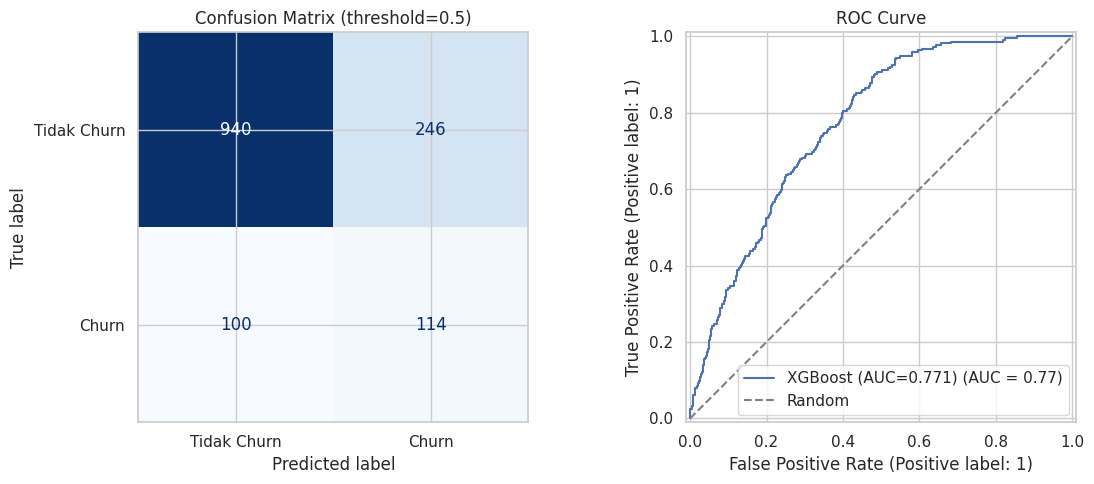

True Negative  (benar prediksi tidak churn) : 940
False Positive (salah prediksi churn)        : 246  <- cost: promo terbuang
False Negative (gagal deteksi churn)         : 100  <- cost: kehilangan pelanggan!
True Positive  (benar prediksi churn)        : 114


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = np.array(eval_results['confusion_matrix'])
ConfusionMatrixDisplay(cm, display_labels=['Tidak Churn', 'Churn']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (threshold=0.5)')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, eval_results['y_proba'], ax=axes[1],
    name=f"XGBoost (AUC={eval_results['roc_auc']:.3f})"
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (benar prediksi tidak churn) : {tn}")
print(f"False Positive (salah prediksi churn)        : {fp}  <- cost: promo terbuang")
print(f"False Negative (gagal deteksi churn)         : {fn}  <- cost: kehilangan pelanggan!")
print(f"True Positive  (benar prediksi churn)        : {tp}")


## 4. Cross-Validation (5-Fold Stratified)

Memastikan performa model konsisten dan tidak tergantung pada satu
kombinasi split train/test tertentu (menghindari *lucky split*).


[2026-06-15 06:44:01] INFO | src.model | Cross-validation (5-fold) ROC-AUC: mean=0.7732, std=0.0067, scores=[0.7637, 0.779, 0.7766, 0.7669, 0.7799]


ROC-AUC per fold: [0.7637 0.779  0.7766 0.7669 0.7799]
Mean ROC-AUC    : 0.7732
Std ROC-AUC     : 0.0067


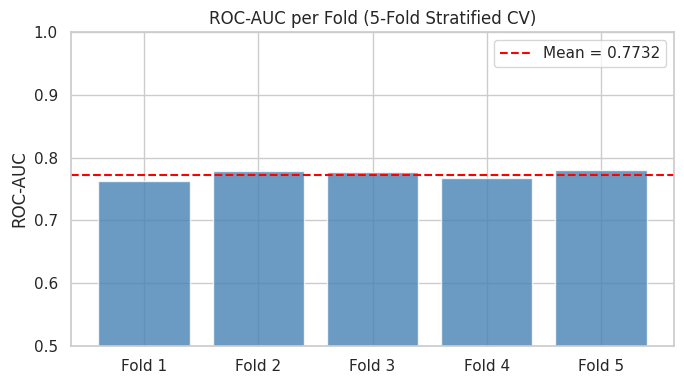


-> Std deviasi rendah (0.0067) menunjukkan model STABIL
   dan tidak overfit pada split tertentu.


In [6]:
X_all = df.drop(columns=[ID_COL, TARGET_COL])
y_all = df[TARGET_COL]

cv_results = cross_validate_model(X_all, y_all)

print(f"ROC-AUC per fold: {np.round(cv_results['scores'], 4)}")
print(f"Mean ROC-AUC    : {cv_results['mean']:.4f}")
print(f"Std ROC-AUC     : {cv_results['std']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_results['scores']))]
ax.bar(folds, cv_results['scores'], color='steelblue', alpha=0.8)
ax.axhline(cv_results['mean'], color='red', linestyle='--',
           label=f"Mean = {cv_results['mean']:.4f}")
ax.set_ylim(0.5, 1.0)
ax.set_title('ROC-AUC per Fold (5-Fold Stratified CV)')
ax.set_ylabel('ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n-> Std deviasi rendah ({cv_results['std']:.4f}) menunjukkan model STABIL")
print("   dan tidak overfit pada split tertentu.")


## 5. Feature Importance

Fitur mana yang paling berkontribusi terhadap prediksi model?
Ini menjadi dasar untuk interpretasi bisnis dan menentukan
area fokus tim retensi.


                feature  importance
     skor_kepuasan_csat    0.279031
   jumlah_komplain_6bln    0.187137
                  paket    0.061377
 punya_streaming_bundle    0.053555
   punya_ewallet_linked    0.044049
           tenure_bulan    0.040188
       engagement_score    0.033723
   pernah_upgrade_paket    0.029908
total_pemakaian_data_gb    0.028830
    frekuensi_login_app    0.027419
         usage_per_cost    0.026908
                 gender    0.026781
                   kota    0.025066
           metode_bayar    0.024937
          biaya_bulanan    0.023826


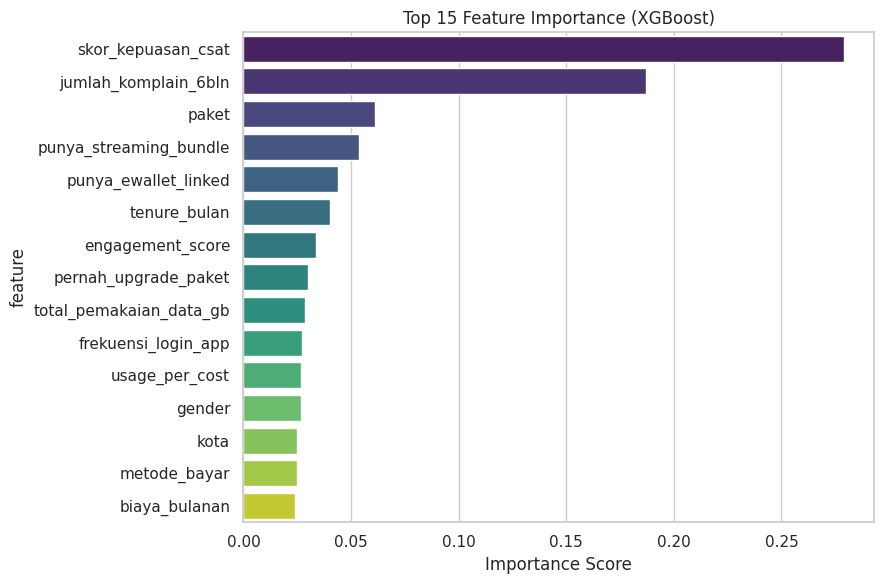

In [7]:
feat_imp = get_feature_importance(model, feature_names, top_n=15)
print(feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x='importance', y='feature', data=feat_imp, ax=ax,
            hue='feature', legend=False, palette='viridis')
ax.set_title('Top 15 Feature Importance (XGBoost)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 6. Interpretasi dengan SHAP

SHAP (SHapley Additive exPlanations) memberikan interpretasi yang lebih
kaya dibanding feature importance biasa:

- Summary plot: menunjukkan arah pengaruh (positif/negatif) setiap
  fitur terhadap prediksi churn, bukan hanya magnitude.
- Berguna untuk menjelaskan mengapa seorang pelanggan diprediksi
  high-risk kepada stakeholder non-teknis.


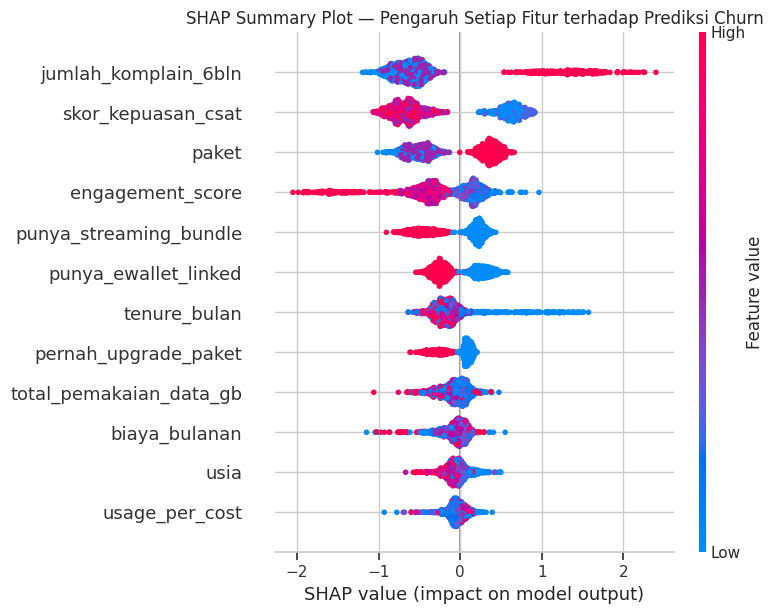

Interpretasi warna:
  - Merah  = nilai fitur TINGGI
  - Biru   = nilai fitur RENDAH
  - Posisi kanan (SHAP value > 0) = mendorong prediksi ke arah CHURN
  - Posisi kiri  (SHAP value < 0) = mendorong prediksi ke arah TIDAK CHURN


In [8]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.title('SHAP Summary Plot — Pengaruh Setiap Fitur terhadap Prediksi Churn')
plt.tight_layout()
plt.show()

print("Interpretasi warna:")
print("  - Merah  = nilai fitur TINGGI")
print("  - Biru   = nilai fitur RENDAH")
print("  - Posisi kanan (SHAP value > 0) = mendorong prediksi ke arah CHURN")
print("  - Posisi kiri  (SHAP value < 0) = mendorong prediksi ke arah TIDAK CHURN")


Pelanggan index 581 di test set:
  Probabilitas churn (model): 93.3%
  Actual churn              : 1


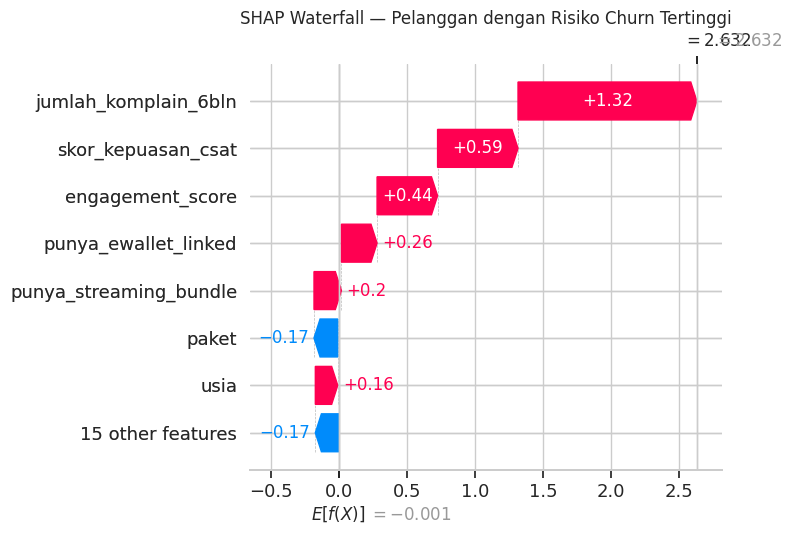

In [9]:
# Contoh interpretasi individual: pelanggan dengan probabilitas churn TERTINGGI di test set
idx_highest_risk = np.argmax(eval_results['y_proba'])

print(f"Pelanggan index {idx_highest_risk} di test set:")
print(f"  Probabilitas churn (model): {eval_results['y_proba'][idx_highest_risk]*100:.1f}%")
print(f"  Actual churn              : {y_test.iloc[idx_highest_risk]}")

fig, ax = plt.subplots(figsize=(10, 4))
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[idx_highest_risk],
    feature_names=feature_names, show=False, max_display=8
)
plt.title(f'SHAP Waterfall — Pelanggan dengan Risiko Churn Tertinggi')
plt.tight_layout()
plt.show()


## 7. Threshold Tuning untuk Optimasi Bisnis

Model mengeluarkan **probabilitas**, bukan keputusan biner langsung.
Threshold default `predict()` adalah 0.5 belum tentu optimal
secara bisnis. 
analisis trade-off Precision vs Recall pada berbagai threshold untuk menemukan titik optimal sesuai *cost-benefit* program retensi.

Asumsi cost-benefit:
- Biaya promo retensi per pelanggan: Rp 50.000 (sekali, voucher + diskon)
- Rata-rata revenue bulanan per pelanggan (ARPU): Rp 100.000
- Horizon retensi yang dihitung: 6 bulan ke depan (revenue berulang vs cost sekali) --
  ini merepresentasikan *minimum expected lifetime* tambahan dari pelanggan
  yang berhasil diretensi sebelum kemungkinan churn berikutnya muncul lagi.
- Jika pelanggan churn dan TIDAK diberi promo -> revenue hilang sepenuhnya
- Jika pelanggan diberi promo dan TETAP churn -> rugi biaya promo saja
- Jika pelanggan diberi promo dan BERHASIL ditahan (asumsi 40% efektivitas)
  -> revenue mengalir selama horizon retensi, dikurangi biaya promo (sekali)

Logika ini penting: biaya promo bersifat one-time, sedangkan revenue
yang diselamatkan bersifat recurring selama pelanggan bertahan maka
perbandingan yang adil adalah terhadap revenue multi-bulan, bukan 1 bulan.
Payback period (waktu hingga net impact positif) juga dihitung sebagai
indikator tambahan ini lebih intuitif bagi stakeholder finance
dibanding ROI pada horizon tunggal yang arbitrer.

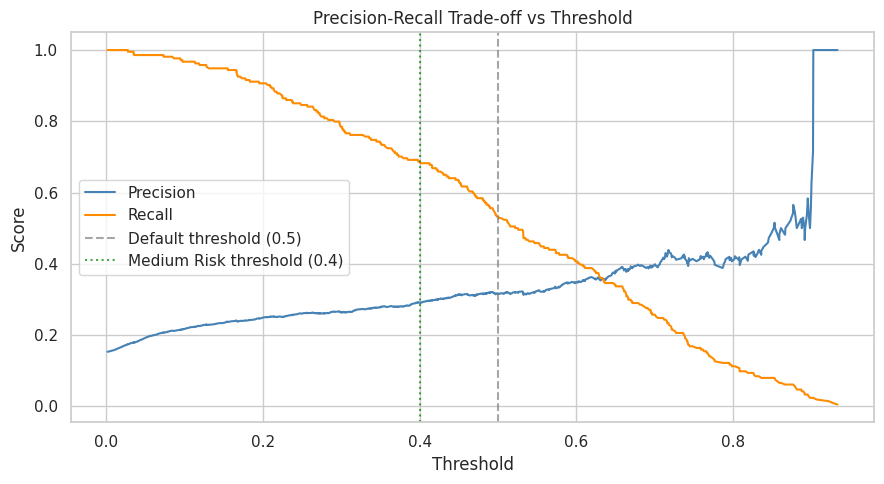

In [10]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, eval_results['y_proba'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='darkorange')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
ax.axvline(RISK_THRESHOLDS['medium'], color='green', linestyle=':', alpha=0.7,
           label=f"Medium Risk threshold ({RISK_THRESHOLDS['medium']})")
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall Trade-off vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
# Simulasi business impact pada beberapa threshold
ARPU = 100_000          # Rp per bulan (recurring)
COST_PROMO = 50_000      # Rp per pelanggan yang ditargetkan (one-time)
RETENTION_EFFECTIVENESS = 0.40  # 40% pelanggan high-risk yang ditarget berhasil ditahan
RETENTION_HORIZON_MONTHS = 6    # horizon revenue yang diselamatkan (bulan)

def simulate_business_impact(y_true, y_proba, threshold):
    y_pred_t = (y_proba >= threshold).astype(int)
    tp = ((y_pred_t == 1) & (y_true == 1)).sum()
    fp = ((y_pred_t == 1) & (y_true == 0)).sum()
    fn = ((y_pred_t == 0) & (y_true == 1)).sum()

    n_targeted = tp + fp
    cost_promo_total = n_targeted * COST_PROMO  # one-time cost

    # Revenue saved = pelanggan churn yang ditargetkan & berhasil ditahan,
    # mengalir selama RETENTION_HORIZON_MONTHS bulan (recurring revenue)
    customers_retained = tp * RETENTION_EFFECTIVENESS
    monthly_revenue_saved = customers_retained * ARPU
    revenue_saved = monthly_revenue_saved * RETENTION_HORIZON_MONTHS

    revenue_lost_fn = fn * ARPU  # pelanggan churn yang tidak ditangkap, revenue bulanan hilang

    net_impact = revenue_saved - cost_promo_total
    payback_months = (cost_promo_total / monthly_revenue_saved) if monthly_revenue_saved > 0 else float('inf')

    return {
        'threshold': threshold,
        'n_targeted': n_targeted,
        'tp': tp, 'fp': fp, 'fn': fn,
        'cost_promo': cost_promo_total,
        'revenue_saved_6mo': revenue_saved,
        'net_impact_6mo': net_impact,
        'payback_months': payback_months,
        'revenue_lost_fn': revenue_lost_fn,
    }

results_sim = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    results_sim.append(simulate_business_impact(y_test.values, eval_results['y_proba'], t))

sim_df = pd.DataFrame(results_sim)
sim_df_display = sim_df.copy()
for col in ['cost_promo', 'revenue_saved_6mo', 'net_impact_6mo', 'revenue_lost_fn']:
    sim_df_display[col] = sim_df_display[col].apply(lambda x: f"Rp {x:,.0f}")
sim_df_display['payback_months'] = sim_df_display['payback_months'].apply(lambda x: f"{x:.1f}")
print(sim_df_display.to_string(index=False))

best_threshold = sim_df.loc[sim_df['net_impact_6mo'].idxmax(), 'threshold']
print(f"\n-> Threshold dengan net_impact tertinggi (per 1400 pelanggan test, horizon {RETENTION_HORIZON_MONTHS} bulan): {best_threshold}")
print(f"   Pada threshold ini, payback period = {sim_df.loc[sim_df['threshold']==best_threshold, 'payback_months'].values[0]:.1f} bulan")
print("\n   Catatan: ini SIMULASI dengan asumsi ilustratif. Di production,")
print("   parameter ARPU, COST_PROMO, RETENTION_EFFECTIVENESS, dan")
print("   RETENTION_HORIZON_MONTHS harus divalidasi dengan data historis")
print("   tim Finance & Marketing.")

 threshold  n_targeted  tp  fp  fn    cost_promo revenue_saved_6mo net_impact_6mo payback_months revenue_lost_fn
       0.3         636 168 468  46 Rp 31,800,000     Rp 40,320,000   Rp 8,520,000            4.7    Rp 4,600,000
       0.4         505 147 358  67 Rp 25,250,000     Rp 35,280,000  Rp 10,030,000            4.3    Rp 6,700,000
       0.5         360 114 246 100 Rp 18,000,000     Rp 27,360,000   Rp 9,360,000            3.9   Rp 10,000,000
       0.6         249  87 162 127 Rp 12,450,000     Rp 20,880,000   Rp 8,430,000            3.6   Rp 12,700,000
       0.7         138  55  83 159  Rp 6,900,000     Rp 13,200,000   Rp 6,300,000            3.1   Rp 15,900,000
       0.8          58  24  34 190  Rp 2,900,000      Rp 5,760,000   Rp 2,860,000            3.0   Rp 19,000,000

-> Threshold dengan net_impact tertinggi (per 1400 pelanggan test, horizon 6 bulan): 0.4
   Pada threshold ini, payback period = 4.3 bulan

   Catatan: ini SIMULASI dengan asumsi ilustratif. Di production,
  

## 8. Segmentasi Risiko: High / Medium / Low

Untuk operasional tim retensi, probabilitas kontinu diubah menjadi
3 segmen aksi yang jelas (lihat `src/utils.py -> segment_risk()`):

* High Risk: probabilitas >= 0.70
Aksi: kontak personal CS dalam 48 jam + voucher 10GB + diskon 20%

* Medium Risk: probabilitas 0.40 - 0.69
Aksi: push notif персонalisasi + tawaran upgrade bundle

* Low Risk: probabilitas < 0.40
Aksi: program loyalty points + cross-sell e-wallet


              jumlah_pelanggan  actual_churn_rate  avg_predicted_proba  \
risk_segment                                                             
High Risk                  138               39.9                0.791   
Medium Risk                367               25.1                0.541   
Low Risk                   895                7.5                0.140   

              persentase_populasi  
risk_segment                       
High Risk                     9.9  
Medium Risk                  26.2  
Low Risk                     63.9  


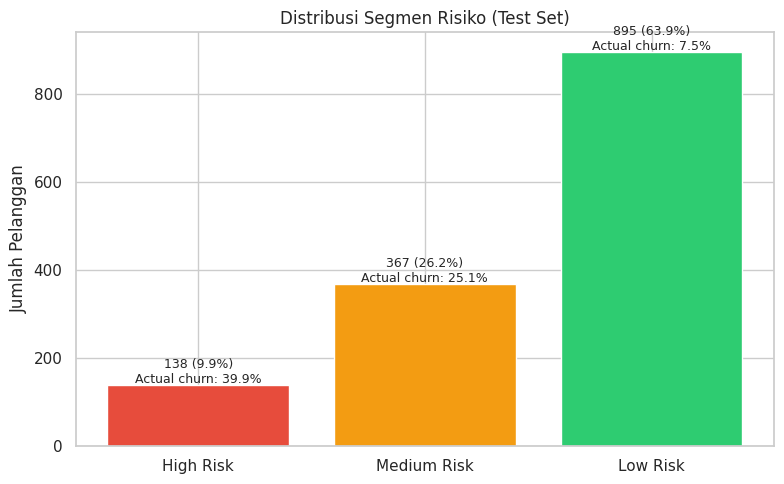

In [12]:
df_test_result = X_test.copy()
df_test_result['customer_id'] = df.loc[X_test.index, 'customer_id'].values
df_test_result['actual_churn'] = y_test.values
df_test_result['churn_probability'] = eval_results['y_proba']
df_test_result['risk_segment'] = df_test_result['churn_probability'].apply(segment_risk)

segment_summary = df_test_result.groupby('risk_segment').agg(
    jumlah_pelanggan=('customer_id', 'count'),
    actual_churn_rate=('actual_churn', 'mean'),
    avg_predicted_proba=('churn_probability', 'mean'),
).round(3)
segment_summary['actual_churn_rate'] = (segment_summary['actual_churn_rate'] * 100).round(1)
segment_summary['persentase_populasi'] = (segment_summary['jumlah_pelanggan'] / len(df_test_result) * 100).round(1)
segment_summary = segment_summary.reindex(['High Risk', 'Medium Risk', 'Low Risk'])

print(segment_summary)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'}
bars = ax.bar(segment_summary.index, segment_summary['jumlah_pelanggan'],
               color=[colors[s] for s in segment_summary.index])
for bar, (idx, row) in zip(bars, segment_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(row['jumlah_pelanggan'])} ({row['persentase_populasi']}%)\nActual churn: {row['actual_churn_rate']}%",
            ha='center', fontsize=9)
ax.set_title('Distribusi Segmen Risiko (Test Set)')
ax.set_ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()


### Validasi Segmentasi

kolom actual_churn_rate jika model bekerja dengan baik, actual churn rate harus meningkat monoton dari Low Risk -> Medium Risk -> High Risk. Ini adalah bukti bahwa segmen "High Risk" benar-benar berisi pelanggan yang secara nyata lebih sering
churn — bukan sekadar angka probabilitas tanpa makna.


In [13]:
ordered = segment_summary.loc[['Low Risk', 'Medium Risk', 'High Risk'], 'actual_churn_rate']
is_monotonic = all(ordered.iloc[i] <= ordered.iloc[i+1] for i in range(len(ordered)-1))

print(f"Actual churn rate (Low -> Medium -> High): {ordered.tolist()}")
print(f"Monotonic increasing? {is_monotonic}")

if is_monotonic:
    print("\n[VALID] Segmentasi risiko KONSISTEN dengan realita -- model dapat")
    print("        dipercaya untuk memprioritaskan target retensi.")
else:
    print("\n[CAUTION] Segmentasi tidak monotonic -- perlu investigasi lebih lanjut")
    print("          sebelum dipakai untuk keputusan bisnis.")


Actual churn rate (Low -> Medium -> High): [7.5, 25.1, 39.9]
Monotonic increasing? True

[VALID] Segmentasi risiko KONSISTEN dengan realita -- model dapat
        dipercaya untuk memprioritaskan target retensi.


## 9. Estimasi Business Impact (Skala Penuh)

Mengekstrapolasi hasil test set (1400 pelanggan) ke basis pelanggan
yang lebih besar (misal 100.000 pelanggan), untuk memberikan gambaran
skala dampak program retensi berbasis model ini.


In [14]:
TOTAL_CUSTOMER_BASE = 100_000
SCALE_FACTOR = TOTAL_CUSTOMER_BASE / len(df_test_result)

high_risk_count = (df_test_result['risk_segment'] == 'High Risk').sum()
high_risk_scaled = int(high_risk_count * SCALE_FACTOR)

# Asumsi: dari high-risk yang benar2 churn, 40% berhasil ditahan via promo
actual_high_risk_churners = df_test_result[
    (df_test_result['risk_segment'] == 'High Risk') & (df_test_result['actual_churn'] == 1)
].shape[0]
actual_high_risk_churners_scaled = int(actual_high_risk_churners * SCALE_FACTOR)

saved_customers = int(actual_high_risk_churners_scaled * RETENTION_EFFECTIVENESS)

# Revenue saved bersifat RECURRING selama horizon retensi (bulan)
monthly_revenue_saved = saved_customers * ARPU
revenue_saved_horizon = monthly_revenue_saved * RETENTION_HORIZON_MONTHS
annual_revenue_saved = monthly_revenue_saved * 12

# Promo cost bersifat ONE-TIME (ditargetkan ke seluruh segmen High Risk)
promo_cost_total = high_risk_scaled * COST_PROMO

net_impact_horizon = revenue_saved_horizon - promo_cost_total
payback_months = promo_cost_total / monthly_revenue_saved if monthly_revenue_saved > 0 else float('inf')

print("=== ESTIMASI BUSINESS IMPACT (Skala 100.000 Pelanggan) ===")
print(f"Total pelanggan High Risk                  : {high_risk_scaled:,}")
print(f"  - yang BENAR-BENAR akan churn             : {actual_high_risk_churners_scaled:,}")
print(f"  - asumsi berhasil ditahan ({RETENTION_EFFECTIVENESS*100:.0f}% efektivitas) : {saved_customers:,}")
print(f"\nBiaya program promo (one-time)              : Rp {promo_cost_total:,}")
print(f"Revenue terselamatkan (per bulan, recurring) : Rp {monthly_revenue_saved:,}")
print(f"Revenue terselamatkan ({RETENTION_HORIZON_MONTHS} bulan horizon)        : Rp {revenue_saved_horizon:,}")
print(f"Revenue terselamatkan (tahunan)              : Rp {annual_revenue_saved:,}")
print(f"\nNet impact ({RETENTION_HORIZON_MONTHS} bulan horizon)                 : Rp {net_impact_horizon:,}")
print(f"ROI program ({RETENTION_HORIZON_MONTHS} bulan horizon)                  : {net_impact_horizon / promo_cost_total * 100:.1f}%")
print(f"Payback period                               : {payback_months:.1f} bulan")
print(f"\n-> Setelah payback period ({payback_months:.1f} bulan), program ini")
print(f"   menghasilkan net POSITIVE Rp {monthly_revenue_saved:,.0f} per bulan")
print(f"   secara recurring selama pelanggan yang diretensi tetap aktif.")
print("\n*Catatan: angka ARPU, cost promo, efektivitas retensi, dan horizon")
print(" adalah ASUMSI ILUSTRATIF untuk demonstrasi metodologi. Untuk")
print(" keputusan investasi nyata, gunakan data historis aktual perusahaan.")

=== ESTIMASI BUSINESS IMPACT (Skala 100.000 Pelanggan) ===
Total pelanggan High Risk                  : 9,857
  - yang BENAR-BENAR akan churn             : 3,928
  - asumsi berhasil ditahan (40% efektivitas) : 1,571

Biaya program promo (one-time)              : Rp 492,850,000
Revenue terselamatkan (per bulan, recurring) : Rp 157,100,000
Revenue terselamatkan (6 bulan horizon)        : Rp 942,600,000
Revenue terselamatkan (tahunan)              : Rp 1,885,200,000

Net impact (6 bulan horizon)                 : Rp 449,750,000
ROI program (6 bulan horizon)                  : 91.3%
Payback period                               : 3.1 bulan

-> Setelah payback period (3.1 bulan), program ini
   menghasilkan net POSITIVE Rp 157,100,000 per bulan
   secara recurring selama pelanggan yang diretensi tetap aktif.

*Catatan: angka ARPU, cost promo, efektivitas retensi, dan horizon
 adalah ASUMSI ILUSTRATIF untuk demonstrasi metodologi. Untuk
 keputusan investasi nyata, gunakan data historis aktual

## 10. Simpan Model & Artifacts

Model final, daftar fitur, dan metrics summary disimpan ke `models/`
untuk dipakai oleh Streamlit app.


In [15]:
metrics = {
    'classification_report': eval_results['classification_report'],
    'roc_auc': eval_results['roc_auc'],
    'confusion_matrix': eval_results['confusion_matrix'],
    'roc_curve': eval_results['roc_curve'],
    'cv_roc_auc_mean': cv_results['mean'],
    'cv_roc_auc_std': cv_results['std'],
    'cv_scores': cv_results['scores'],
    'feature_importance': feat_imp.to_dict(orient='records'),
    'n_train': len(X_train),
    'n_test': len(X_test),
}

save_model_artifacts(model, feature_names, metrics)
print("Model & artifacts berhasil disimpan ke folder models/:")
print("  - churn_model_xgb.pkl")
print("  - feature_list.pkl")
print("  - metrics.pkl")


[2026-06-15 06:44:14] INFO | src.model | Model artifacts saved: /home/claude/telco-churn-2026/models/churn_model_xgb.pkl, /home/claude/telco-churn-2026/models/feature_list.pkl, /home/claude/telco-churn-2026/models/metrics.pkl


Model & artifacts berhasil disimpan ke folder models/:
  - churn_model_xgb.pkl
  - feature_list.pkl
  - metrics.pkl


## 11. Ringkasan Hasil & Rekomendasi Bisnis Final

### Performa Model
* ROC-AUC (test): sekitar 0.77
* ROC-AUC (5-fold CV): sekitar 0.77 ± 0.01
* Recall (churn): sekitar 0.53
* Precision (churn): sekitar 0.32

### Top Driver Churn (Feature Importance)
1. `skor_kepuasan_csat` — driver TERKUAT. Setiap penurunan CSAT berkorelasi
   langsung dengan kenaikan risiko churn.
2. `jumlah_komplain_6bln` — driver kedua. Pelanggan dengan ≥2 komplain
   dalam 6 bulan adalah target prioritas *proactive outreach*.
3. `paket` (terutama Prabayar) — segmen dengan churn rate struktural lebih
   tinggi karena tidak ada kontrak/komitmen.
4. `punya_streaming_bundle` & `punya_ewallet_linked` — fitur "stickiness";
   mendorong adopsi bundle ini sebagai strategi retensi proaktif.

### Rekomendasi Aksi per Segmen

* High Risk (prob >= 0.70): kontak personal CS dalam 48 jam, berikan voucher data 10GB + diskon 20% untuk bulan berikutnya. Jika tenure < 6 bulan, eskalasi ke tim retensi senior.
* Medium Risk (0.40-0.69): kirim push notification yang dipersonalisasi, lalu tawarkan upgrade ke paket bundle streaming.
* Low Risk (< 0.40): jalankan program loyalty points dan cross-sell e-wallet linking.

### Rekomendasi Strategis Tambahan
1. Program "First 6 Months: pelanggan baru (tenure < 6 bulan) butuh
   onboarding intensif & monitoring CSAT lebih sering — fase ini adalah
   window kritis churn.
2. Early Warning System: integrasikan model ini ke CRM agar tim CS
   mendapat notifikasi otomatis saat skor CSAT pelanggan turun ≤2 atau
   komplain ke-2 tercatat — intervensi SEBELUM churn terjadi.
3. Bundle Adoption Campaign**: dorong pelanggan Prabayar tanpa bundle
   untuk mencoba streaming bundle / e-wallet linking dengan trial gratis
   1 bulan — keduanya terbukti menurunkan churn rate secara signifikan.
4. Monitoring Model Drift: jalankan retraining berkala (misal triwulan)
   karena perilaku pelanggan & lanskap kompetitif (masuknya provider baru
   seperti Starlink) dapat mengubah pola churn dari waktu ke waktu.

### Validasi Business Case

Simulasi menunjukkan payback period 3 bulan untuk program retensi
yang menargetkan segmen High Risk: biaya promo (one-time) tertutup oleh
revenue yang diselamatkan dalam 3 bulan, dan setelahnya program
menghasilkan net positive secara recurring selama pelanggan tetap aktif.
Ini adalah business case yang layak dijalankan dengan asumsi
konservatif (efektivitas retensi 40%) - jika efektivitas aktual lebih
tinggi (misal dengan personalisasi yang lebih baik), payback period akan
lebih singkat lagi.

### Limitasi & Next Steps
- Recall 0.53 berarti ~47% pelanggan yang benar-benar churn TIDAK
  tertangkap pada threshold 0.5. Untuk operasional, gunakan segmentasi
  3-tier (bukan threshold tunggal) agar Medium Risk juga mendapat
  perhatian sebagai *secondary net*.
- Dataset bersifat sintetis; saat dataset CRM real tersedia, retraining
  ulang WAJIB dilakukan dan performa divalidasi ulang.
- Pertimbangkan model survival analysis (waktu-hingga-churn) sebagai
  pengembangan lanjutan untuk prioritisasi yang lebih granular.